In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from datasets import load_from_disk


RANDOM_SEED = 42

project_root = Path.cwd()

if project_root.name == "notebooks":
    project_root = project_root.parent

data_path = project_root / "data" / "processed" / "imdb_splits"
reports_path = project_root / "reports"

reports_path.mkdir(parents=True, exist_ok=True)

dataset = load_from_disk(str(data_path))

print(dataset)

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 20000
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 5000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
})


In [2]:
from pathlib import Path

from datasets import load_from_disk


PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "imdb_clean_splits"
)

dataset = load_from_disk(str(DATA_PATH))

print("Dataset path:")
print(DATA_PATH)

print("\nLoaded dataset:")
print(dataset)

print("\nSplit sizes:")
print("Train:", len(dataset["train"]))
print("Validation:", len(dataset["validation"]))
print("Test:", len(dataset["test"]))

Dataset path:
d:\app\ai\Sentiment Analysis Traditional ML vs Transformers\data\processed\imdb_clean_splits

Loaded dataset:
DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 19823
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 4956
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
})

Split sizes:
Train: 19823
Validation: 4956
Test: 25000


In [3]:
train_df = dataset["train"].to_pandas()
validation_df = dataset["validation"].to_pandas()

label_names = dataset["train"].features["label"].names
id_to_label = {
    label_id: label_name
    for label_id, label_name in enumerate(label_names)
}

train_df["label_name"] = train_df["label"].map(id_to_label)
validation_df["label_name"] = validation_df["label"].map(id_to_label)

print("Label mapping:", id_to_label)
print("Train shape:", train_df.shape)
print("Validation shape:", validation_df.shape)

Label mapping: {0: 'neg', 1: 'pos'}
Train shape: (19823, 3)
Validation shape: (4956, 3)


In [4]:
preview = train_df.copy()

preview["text_preview"] = (
    preview["text"]
    .str.replace("<br />", " ", regex=False)
    .str.slice(0, 300)
)

preview[
    ["text_preview", "label", "label_name"]
].sample(
    n=5,
    random_state=42,
)

,text_preview,label,label_name
2235,I watched the Canadian videotape of this movie...,0,neg
4807,An unforgettable masterpiece from the creator ...,1,pos
10726,I think the deal with this movie is that it ha...,1,pos
6954,Very well done and spooky horror movie from po...,1,pos
17103,Steven Spielberg wanted to win an Oscar so bad...,1,pos


In [5]:
class_counts = train_df["label_name"].value_counts().sort_index()
class_percentages = (
    train_df["label_name"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
)

class_summary = pd.DataFrame(
    {
        "count": class_counts,
        "percentage": class_percentages,
    }
)

class_summary

,count,percentage
label_name,,
neg,9869,49.785603
pos,9954,50.214397


In [6]:
class_counts = train_df["label_name"].value_counts().sort_index()
class_percentages = (
    train_df["label_name"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
)

class_summary = pd.DataFrame(
    {
        "count": class_counts,
        "percentage": class_percentages,
    }
)

class_summary

,count,percentage
label_name,,
neg,9869,49.785603
pos,9954,50.214397


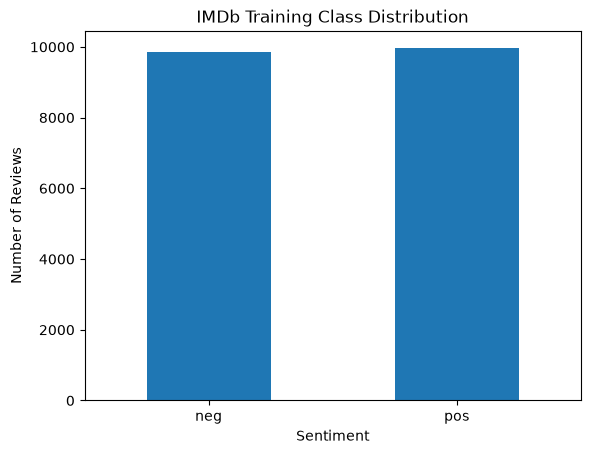

In [7]:
class_counts.plot(
    kind="bar",
    title="IMDb Training Class Distribution",
)

plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=0)
plt.show()

In [8]:
missing_texts = train_df["text"].isna().sum()

empty_texts = (
    train_df["text"]
    .fillna("")
    .str.strip()
    .eq("")
    .sum()
)

print("Missing texts:", missing_texts)
print("Empty texts:", empty_texts)

Missing texts: 0
Empty texts: 0


In [9]:
duplicate_count = train_df.duplicated(
    subset=["text"],
    keep=False,
).sum()

unique_duplicate_groups = train_df.duplicated(
    subset=["text"],
).sum()

print("Rows involved in duplicate groups:", duplicate_count)
print("Extra duplicated rows:", unique_duplicate_groups)
train_texts = set(train_df["text"])
validation_texts = set(validation_df["text"])

train_validation_overlap = train_texts.intersection(validation_texts)

print(
    "Identical reviews shared between train and validation:",
    len(train_validation_overlap),
)

Rows involved in duplicate groups: 0
Extra duplicated rows: 0
Identical reviews shared between train and validation: 0


In [10]:
train_df["character_count"] = train_df["text"].str.len()

train_df["word_count"] = (
    train_df["text"]
    .str.split()
    .str.len()
)
train_df[
    ["character_count", "word_count"]
].describe(
    percentiles=[0.50, 0.75, 0.90, 0.95, 0.99]
)

,character_count,word_count
count,19823.000000,19823.000000
mean,1322.804722,233.402210
std,1000.446172,173.319132
min,52.000000,10.000000
50%,979.000000,174.000000
75%,1607.000000,283.000000
90%,2597.800000,455.000000
95%,3416.900000,595.000000
99%,5189.560000,908.780000
max,13704.000000,2470.000000


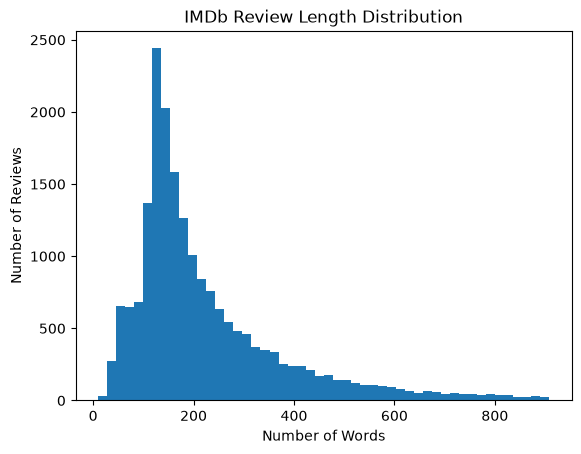

In [11]:
word_limit_99 = train_df["word_count"].quantile(0.99)

train_df.loc[
    train_df["word_count"] <= word_limit_99,
    "word_count",
].plot(
    kind="hist",
    bins=50,
    title="IMDb Review Length Distribution",
)

plt.xlabel("Number of Words")
plt.ylabel("Number of Reviews")
plt.show()

In [12]:
shortest_reviews = train_df.sort_values(
    "word_count",
).loc[
    :,
    ["text", "label_name", "word_count"]
].head(10)

shortest_reviews

,text,label_name,word_count
10055,This movie is terrible but it has some good ef...,neg,10
17985,I wouldn't rent this one even on dollar rental...,neg,10
947,You'd better choose Paul Verhoeven's even if y...,neg,11
1452,"Comment this movie is impossible. Is terrible,...",neg,15
8977,This is the definitive movie version of Hamlet...,pos,17
3145,"I don't know why I like this movie so well, bu...",pos,18
12031,"A rating of ""1"" does not begin to express how ...",neg,18
4198,The characters are unlikeable and the script i...,neg,19
2399,Obviously written for the stage. Lightweight b...,pos,20
12966,Unwatchable. You can't even make it past the f...,neg,21


In [13]:
longest_reviews = train_df.sort_values(
    "word_count",
    ascending=False,
).loc[
    :,
    ["text", "label_name", "word_count"]
].head(5)

longest_reviews

,text,label_name,word_count
8641,Match 1: Tag Team Table Match Bubba Ray and Sp...,pos,2470
2176,Titanic directed by James Cameron presents a f...,pos,1839
17476,**Attention Spoilers**<br /><br />First of all...,pos,1830
8037,*!!- SPOILERS - !!*<br /><br />Before I begin ...,pos,1601
14361,Warning: Does contain spoilers.<br /><br />Ope...,pos,1527


In [14]:
html_pattern = r"<[^>]+>"

contains_html = train_df["text"].str.contains(
    html_pattern,
    regex=True,
    na=False,
)

html_count = contains_html.sum()
html_percentage = contains_html.mean() * 100

print("Reviews containing HTML:", html_count)
print(f"Percentage containing HTML: {html_percentage:.2f}%")
train_df.loc[
    contains_html,
    ["text", "label_name"],
].head(3)

Reviews containing HTML: 11650
Percentage containing HTML: 58.77%


,text,label_name
0,This cool Marvel superhero game pays proper tr...,pos
4,"Forget that this is a ""B"" movie. Forget that i...",pos
5,The pilot is extremely well done. It lays out ...,pos


In [15]:
length_by_label = train_df.groupby(
    "label_name"
)["word_count"].describe()

length_by_label

,count,mean,std,min,25%,50%,75%,max
label_name,,,,,,,,
neg,9869.0,231.126558,166.866863,10.0,128.0,175.0,279.0,1522.0
pos,9954.0,235.658429,179.467379,17.0,126.0,174.0,288.0,2470.0


In [16]:
REPORTS_DIR = PROJECT_ROOT / "reports"
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

In [17]:
eda_summary = pd.DataFrame(
    {
        "metric": [
            "train_rows",
            "validation_rows",
            "negative_train_reviews",
            "positive_train_reviews",
            "missing_train_texts",
            "empty_train_texts",
            "extra_duplicate_train_rows",
            "train_validation_overlap",
            "median_word_count",
            "95th_percentile_word_count",
            "99th_percentile_word_count",
            "html_review_percentage",
        ],
        "value": [
            len(train_df),
            len(validation_df),
            int((train_df["label"] == 0).sum()),
            int((train_df["label"] == 1).sum()),
            int(missing_texts),
            int(empty_texts),
            int(unique_duplicate_groups),
            int(len(train_validation_overlap)),
            float(train_df["word_count"].median()),
            float(train_df["word_count"].quantile(0.95)),
            float(train_df["word_count"].quantile(0.99)),
            float(html_percentage),
        ],
    }
)

eda_summary

,metric,value
0,train_rows,19823.000000
1,validation_rows,4956.000000
2,negative_train_reviews,9869.000000
3,positive_train_reviews,9954.000000
4,missing_train_texts,0.000000
5,empty_train_texts,0.000000
6,extra_duplicate_train_rows,0.000000
7,train_validation_overlap,0.000000
8,median_word_count,174.000000
9,95th_percentile_word_count,595.000000


In [18]:
summary_path = REPORTS_DIR / "eda_summary.csv"

eda_summary.to_csv(
    summary_path,
    index=False,
)

print("Saved to:", summary_path)

Saved to: d:\app\ai\Sentiment Analysis Traditional ML vs Transformers\reports\eda_summary.csv
